# LightGBM — Non-Social Dataset

Binary classification of `success_target` using the **`non_social_dataset.csv`** dataset.

Pipeline:
1. Preprocessing — label-encode categoricals, drop `release_date`
2. Stratified train / test split (80 / 20)
3. Bayesian hyperparameter search with **Optuna** (TPE sampler, 5-fold CV)
   Tuned parameters: `num_leaves` (bucket), `max_depth`, `min_data_in_leaf` (min\_split),
   `feature_fraction` (vcp), `min_gain_to_split` (split)
4. Final model trained on full train set with best params
5. Evaluation: ROC-AUC, PR curve, F1, confusion matrix
6. Feature importance

**Seed**: `611033`
**Class balance**: ~10:1 (failure : success) — handled via `scale_pos_weight` and AUC optimisation.

This dataset uses only **non-social** movie features (metadata, budget, release context). No social/sentiment signal. Serves as the baseline — can movies be predicted as successes from metadata alone?


## 0. Dependencies

Uncomment the install line if packages are missing.

In [1]:
# !pip install lightgbm optuna scikit-learn pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 22.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]━━━━ 5/6 [optuna]alembic]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## 1. Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

SEED = 611033
np.random.seed(SEED)

/home/vscode/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and inspect data

In [3]:
DATA_PATH = "../../data/non_social_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print()
print("Class balance:")
print(df["success_target"].value_counts())
print(f"\nPositive rate: {df['success_target'].mean():.2%}")
df.head()

Shape: (452, 13)

Class balance:
success_target
0    412
1     40
Name: count, dtype: int64

Positive rate: 8.85%


,success_target,release_date,dow,original_language,first_production_country,first_production_company,first_genre,production_budget,opening_theaters,runtime,first_cast,first_director,trailer_count
0,0,2022-12-14,3,en,United States of America,20th Century Studios,Action,400000000,4202,192,Sam Worthington,James Cameron,6.0
1,0,2025-12-17,3,en,United States of America,20th Century Studios,Science Fiction,400000000,3800,198,Sam Worthington,James Cameron,6.0
2,0,2023-09-15,5,en,Bulgaria,Millennium Media,Action,100000000,3518,103,Jason Statham,Scott Waugh,4.0
3,0,2022-12-07,3,en,United States of America,DreamWorks Animation,Animation,110000000,4099,103,Antonio Banderas,Joel Crawford,NaN
4,0,2025-02-27,4,en,Germany,Constantin Film,Action,55000000,1370,101,Milla Jovovich,Paul W. S. Anderson,2.0


In [4]:
print("Dtypes:")
print(df.dtypes)
print("\nNull counts:")
null_counts = df.isna().sum()
print(null_counts[null_counts > 0] if (null_counts > 0).any() else "no nulls")

Dtypes:
success_target                int64
release_date                 object
dow                           int64
original_language            object
first_production_country     object
first_production_company     object
first_genre                  object
production_budget             int64
opening_theaters              int64
runtime                       int64
first_cast                   object
first_director               object
trailer_count               float64
dtype: object

Null counts:
first_production_country    16
first_production_company    18
first_genre                  5
first_cast                   4
first_director               1
trailer_count               42
dtype: int64


## 3. Preprocessing

- Drop `release_date` (the `dow` column already encodes day-of-week)
- Label-encode all string columns — LightGBM handles integer-coded categoricals natively
- `first_cast`, `first_director`, `first_production_company` are kept: high-cardinality is fine for tree boosting


In [5]:
y = df["success_target"].astype(int).values

X = df.drop(columns=["success_target", "release_date"])

# Label-encode every string column
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical features:", categorical_cols)
print("Numeric features    :", numeric_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("\nX shape:", X.shape)
X.head()

Categorical features: ['original_language', 'first_production_country', 'first_production_company', 'first_genre', 'first_cast', 'first_director']
Numeric features    : ['dow', 'production_budget', 'opening_theaters', 'runtime', 'trailer_count']

X shape: (452, 11)


,dow,original_language,first_production_country,first_production_company,first_genre,production_budget,opening_theaters,runtime,first_cast,first_director,trailer_count
0,3,2,23,0,0,400000000,4202,192,310,170,6.0
1,3,2,23,0,14,400000000,3800,198,310,170,6.0
2,5,2,3,133,0,100000000,3518,103,158,353,4.0
3,3,2,23,73,2,110000000,4099,103,22,201,NaN
4,4,2,10,59,0,55000000,1370,101,264,310,2.0


## 4. Train / test split

Stratified 80/20 split to preserve the ~10:1 class ratio in both partitions.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print(f"Train: {len(X_train)} rows  | positives: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Test : {len(X_test)}  rows  | positives: {y_test.sum()} ({y_test.mean():.2%})")

# Scale pos weight to handle imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")

Train: 361 rows  | positives: 32 (8.86%)
Test : 91  rows  | positives: 8 (8.79%)

scale_pos_weight = 10.28


## 5. Optuna hyperparameter search

Five parameters are tuned via Bayesian optimisation (TPE sampler):

| User name | LightGBM param | Search space |
|---|---|---|
| `bucket` | `num_leaves` | int [15, 255] |
| `max_depth` | `max_depth` | int [3, 12] |
| `min_split` | `min_data_in_leaf` | int [5, 100] |
| `vcp` | `feature_fraction` | float [0.4, 1.0] |
| `split` | `min_gain_to_split` | float [0.0, 5.0] |

Objective metric: **mean ROC-AUC** on 5-fold stratified CV of the training set.
`n_estimators` is determined automatically via early stopping inside each fold.


In [7]:
FIXED_PARAMS = dict(
    objective        = "binary",
    metric           = "auc",
    boosting_type    = "gbdt",
    scale_pos_weight = scale_pos_weight,
    learning_rate    = 0.05,
    n_estimators     = 1000,       # early stopping cuts this short
    subsample        = 0.8,
    subsample_freq   = 1,
    verbose          = -1,
    random_state     = SEED,
)

N_FOLDS  = 5
N_TRIALS = 60

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def objective(trial):
    params = {
        **FIXED_PARAMS,
        # ── Tuned hyperparameters ──────────────────────────────────────────
        "num_leaves"        : trial.suggest_int  ("num_leaves",        15,  255),       # bucket
        "max_depth"         : trial.suggest_int  ("max_depth",          3,   12),
        "min_data_in_leaf"  : trial.suggest_int  ("min_data_in_leaf",   5,  100),       # min_split
        "feature_fraction"  : trial.suggest_float("feature_fraction",  0.4,  1.0),     # vcp
        "min_gain_to_split" : trial.suggest_float("min_gain_to_split", 0.0,  5.0),     # split
    }

    fold_aucs = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx],       y_train[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr,
                             categorical_feature=categorical_cols, free_raw_data=False)
        dval   = lgb.Dataset(X_val, label=y_val,
                             categorical_feature=categorical_cols, free_raw_data=False,
                             reference=dtrain)

        n_est = params.pop("n_estimators")
        model = lgb.train(
            params,
            dtrain,
            num_boost_round=n_est,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(stopping_rounds=40, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )
        params["n_estimators"] = n_est

        preds = model.predict(X_val)
        fold_aucs.append(roc_auc_score(y_val, preds))

    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV AUC : {study.best_value:.4f}")
print("Best params :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 46. Best value: 0.903982: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:10<00:00,  5.71it/s]


Best CV AUC : 0.9040
Best params :
  num_leaves: 218
  max_depth: 11
  min_data_in_leaf: 10
  feature_fraction: 0.9617640611585911
  min_gain_to_split: 0.6947333031249288


### Optuna optimisation history

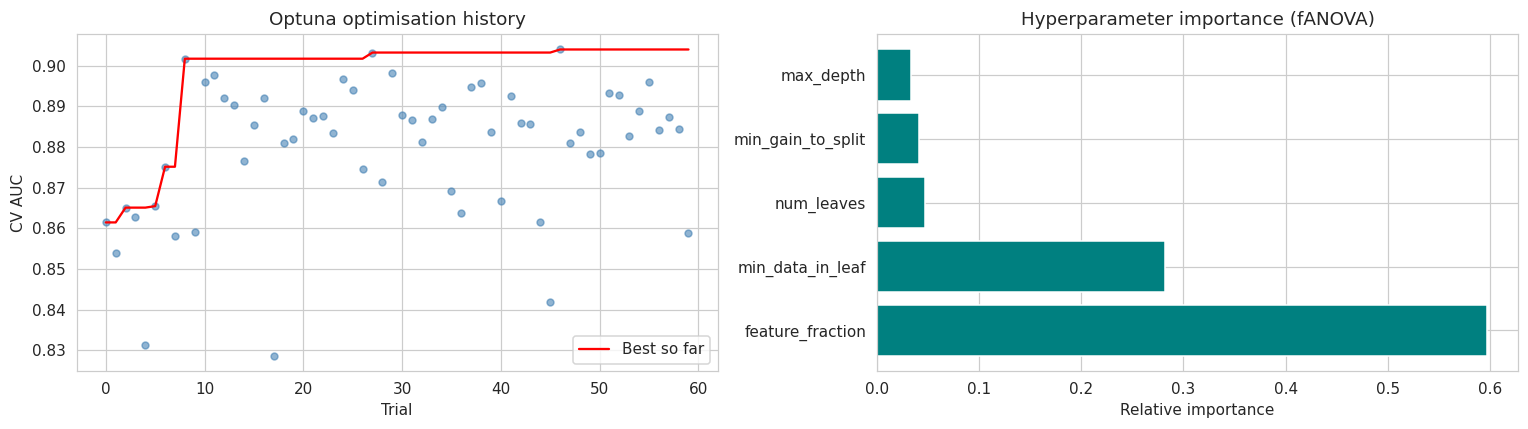

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimisation history
trials_df = study.trials_dataframe()
axes[0].scatter(trials_df["number"], trials_df["value"], alpha=0.6, s=20, color="steelblue")
axes[0].plot(trials_df["number"],
             trials_df["value"].cummax(), color="red", lw=1.5, label="Best so far")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("CV AUC")
axes[0].set_title("Optuna optimisation history")
axes[0].legend()

# Param importances
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color="teal")
axes[1].set_title("Hyperparameter importance (fANOVA)")
axes[1].set_xlabel("Relative importance")

plt.tight_layout()
plt.show()

## 6. Final model

Retrain on the full training set using the best hyperparameters found by Optuna.
Optimal `num_boost_round` is set to the best iteration from a quick CV run with early stopping.


In [9]:
best_params = {
    **FIXED_PARAMS,
    **study.best_params,
}

# Determine optimal n_estimators via one CV split early-stopping run
X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
dtrain_sub = lgb.Dataset(X_tr_sub, label=y_tr_sub,
                          categorical_feature=categorical_cols, free_raw_data=False)
dval_sub   = lgb.Dataset(X_val_sub, label=y_val_sub,
                          categorical_feature=categorical_cols, free_raw_data=False,
                          reference=dtrain_sub)

n_est = best_params.pop("n_estimators")
_tmp = lgb.train(
    best_params,
    dtrain_sub,
    num_boost_round=n_est,
    valid_sets=[dval_sub],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
best_n_rounds = _tmp.best_iteration
best_params["n_estimators"] = n_est
print(f"Optimal number of boosting rounds: {best_n_rounds}")

# Train on full training set
dtrain_full = lgb.Dataset(X_train, label=y_train,
                           categorical_feature=categorical_cols, free_raw_data=False)
final_model = lgb.train(
    best_params,
    dtrain_full,
    num_boost_round=best_n_rounds,
    callbacks=[lgb.log_evaluation(-1)],
)
print("Final model trained.")

Optimal number of boosting rounds: 183
Final model trained.


## 7. Test-set evaluation

In [10]:
y_prob  = final_model.predict(X_test)
y_pred  = (y_prob >= 0.5).astype(int)

# Find threshold that maximises F1 on the test set
thresholds = np.linspace(0.01, 0.99, 99)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_opt  = (y_prob >= best_thresh).astype(int)

roc_auc  = roc_auc_score(y_test, y_prob)
pr_auc   = average_precision_score(y_test, y_prob)

print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"PR-AUC              : {pr_auc:.4f}")
print()
print(f"--- Threshold = 0.50 ---")
print(classification_report(y_test, y_pred, target_names=["Failure", "Success"]))
print(f"--- Threshold = {best_thresh:.2f} (max F1) ---")
print(classification_report(y_test, y_pred_opt, target_names=["Failure", "Success"]))

ROC-AUC             : 0.7831
PR-AUC              : 0.3742

--- Threshold = 0.50 ---
              precision    recall  f1-score   support

     Failure       0.94      0.96      0.95        83
     Success       0.50      0.38      0.43         8

    accuracy                           0.91        91
   macro avg       0.72      0.67      0.69        91
weighted avg       0.90      0.91      0.91        91

--- Threshold = 0.82 (max F1) ---
              precision    recall  f1-score   support

     Failure       0.94      0.99      0.96        83
     Success       0.75      0.38      0.50         8

    accuracy                           0.93        91
   macro avg       0.85      0.68      0.73        91
weighted avg       0.93      0.93      0.92        91



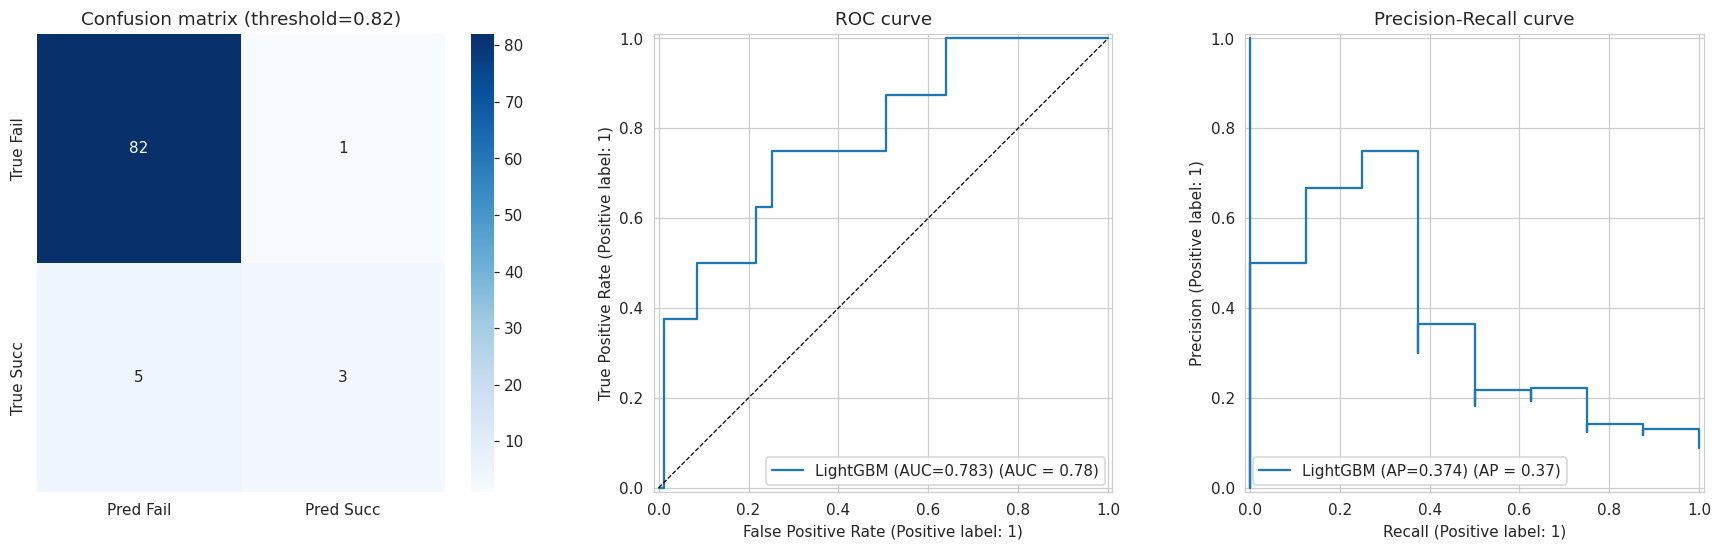

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix (optimal threshold)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred Fail", "Pred Succ"],
            yticklabels=["True Fail", "True Succ"])
axes[0].set_title(f"Confusion matrix (threshold={best_thresh:.2f})")

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=f"LightGBM (AUC={roc_auc:.3f})")
axes[1].plot([0,1],[0,1], "k--", lw=0.8)
axes[1].set_title("ROC curve")

# PR curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2],
                                         name=f"LightGBM (AP={pr_auc:.3f})")
axes[2].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

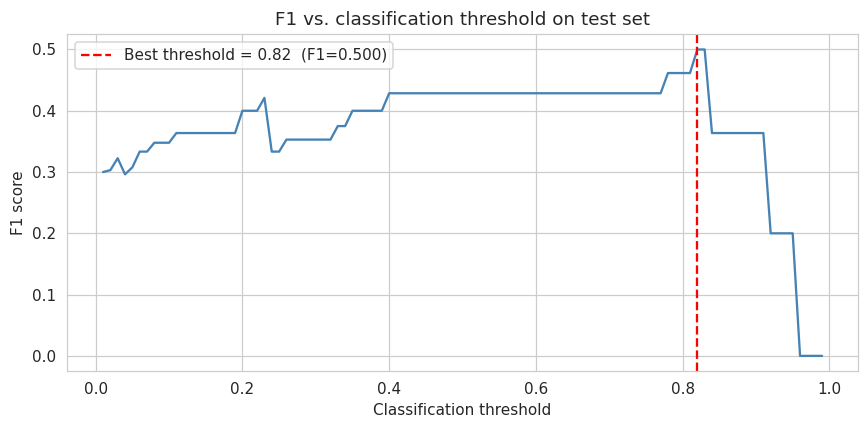

In [12]:
# F1 vs threshold plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color="steelblue")
ax.axvline(best_thresh, color="red", linestyle="--",
           label=f"Best threshold = {best_thresh:.2f}  (F1={max(f1_scores):.3f})")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("F1 score")
ax.set_title("F1 vs. classification threshold on test set")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance

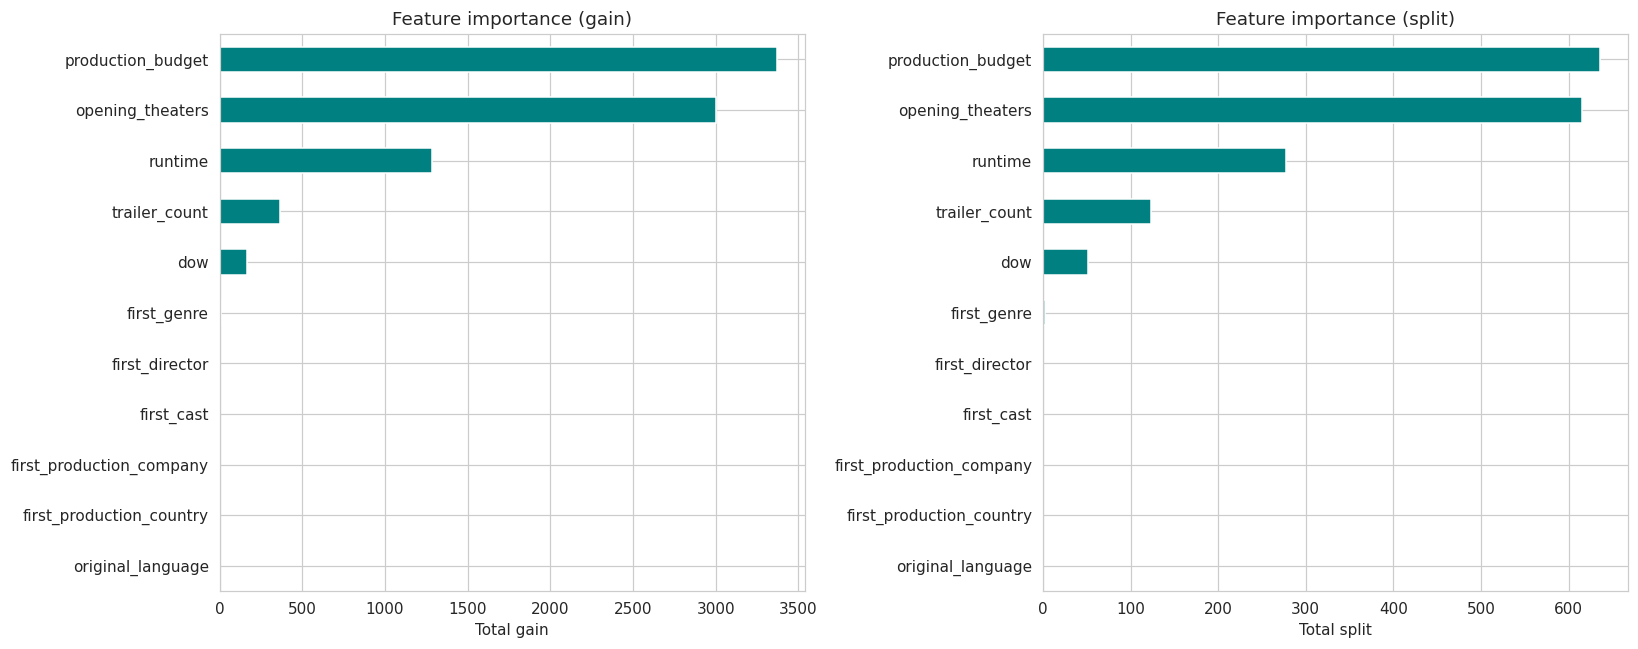

In [13]:
importance_types = ["gain", "split"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, imp_type in zip(axes, importance_types):
    imp = pd.Series(
        final_model.feature_importance(importance_type=imp_type),
        index=X.columns
    ).sort_values(ascending=True)

    imp.plot(kind="barh", ax=ax, color="teal", edgecolor="white")
    ax.set_title(f"Feature importance ({imp_type})")
    ax.set_xlabel(f"Total {imp_type}")

plt.tight_layout()
plt.show()

In [14]:
# Top 10 features by gain
top_gain = pd.Series(
    final_model.feature_importance(importance_type="gain"),
    index=X.columns
).sort_values(ascending=False)

print("Top 10 features by gain:")
print(top_gain.head(10).round(2).to_string())

Top 10 features by gain:
production_budget           3370.63
opening_theaters            3001.14
runtime                     1282.51
trailer_count                366.35
dow                          163.62
first_genre                    5.26
original_language              0.00
first_production_country       0.00
first_production_company       0.00
first_cast                     0.00


## 9. Learning curves

Evaluate train and validation AUC as a function of boosting rounds to check for overfitting.

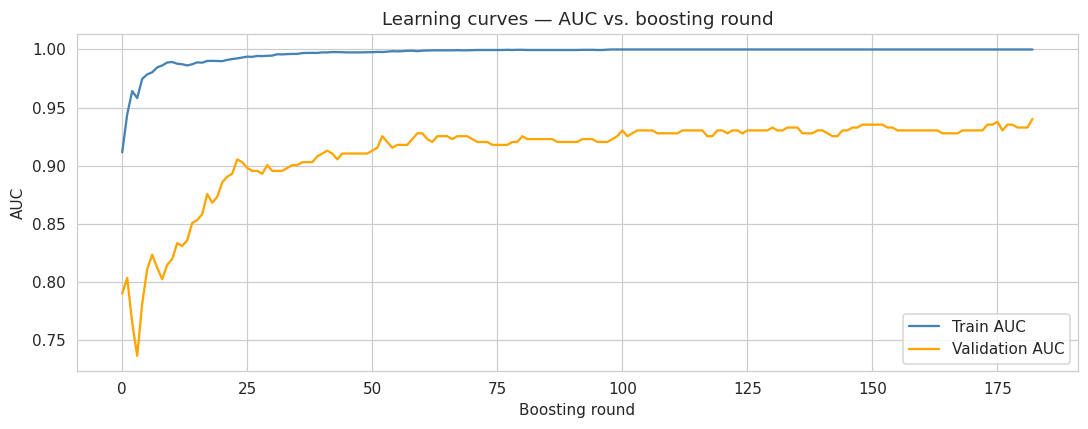

In [15]:
evals_result = {}
X_tr_lc, X_val_lc, y_tr_lc, y_val_lc = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=SEED
)
dtrain_lc = lgb.Dataset(X_tr_lc, label=y_tr_lc,
                          categorical_feature=categorical_cols, free_raw_data=False)
dval_lc   = lgb.Dataset(X_val_lc, label=y_val_lc,
                          categorical_feature=categorical_cols, free_raw_data=False,
                          reference=dtrain_lc)

_lc_params = {**best_params}
n_est_lc = _lc_params.pop("n_estimators")
lgb.train(
    _lc_params,
    dtrain_lc,
    num_boost_round=best_n_rounds,
    valid_sets=[dtrain_lc, dval_lc],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(-1),
    ],
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals_result["train"]["auc"], label="Train AUC", color="steelblue")
ax.plot(evals_result["valid"]["auc"], label="Validation AUC", color="orange")
ax.set_xlabel("Boosting round")
ax.set_ylabel("AUC")
ax.set_title("Learning curves — AUC vs. boosting round")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

In [16]:
print("=" * 55)
print(f"  Dataset : {DATA_PATH}")
print(f"  Seed    : {SEED}")
print("=" * 55)
print(f"  Optuna trials   : {N_TRIALS}")
print(f"  CV folds        : {N_FOLDS}")
print(f"  Best CV AUC     : {study.best_value:.4f}")
print("-" * 55)
print(f"  Test ROC-AUC    : {roc_auc:.4f}")
print(f"  Test PR-AUC     : {pr_auc:.4f}")
print(f"  Best threshold  : {best_thresh:.2f}")
print(f"  F1 @ threshold  : {max(f1_scores):.4f}")
print("-" * 55)
print("  Best hyperparameters:")
for k, v in study.best_params.items():
    alias = {"num_leaves": "bucket", "min_data_in_leaf": "min_split",
             "feature_fraction": "vcp", "min_gain_to_split": "split"}.get(k, k)
    print(f"    {alias:20s} ({k}) = {v}")
print("=" * 55)

  Dataset : ../../data/non_social_dataset.csv
  Seed    : 611033
  Optuna trials   : 60
  CV folds        : 5
  Best CV AUC     : 0.9040
-------------------------------------------------------
  Test ROC-AUC    : 0.7831
  Test PR-AUC     : 0.3742
  Best threshold  : 0.82
  F1 @ threshold  : 0.5000
-------------------------------------------------------
  Best hyperparameters:
    bucket               (num_leaves) = 218
    max_depth            (max_depth) = 11
    min_split            (min_data_in_leaf) = 10
    vcp                  (feature_fraction) = 0.9617640611585911
    split                (min_gain_to_split) = 0.6947333031249288
